#### Auxílio de LLMs para efeitos de teste dos paramêtros e métodos

In [1]:
import random
import numpy as np
import copy
import matplotlib.pyplot as plt
import pandas as pd  


# Problem Parameters
NUM_JOBS = 100 # N jobs
NUM_MACHINES = 10 # M machines
POP_SIZE = 200
NUM_GENERATIONS = 100
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.2

# Randomly generated processing times for jobs and machines 
np.random.seed(200)

processing_times = np.random.randint(1, 20, size=(NUM_JOBS, NUM_MACHINES))
print("Processing Times (Preview):\n", processing_times[:5])


def evaluate_schedule(schedule, processing_times):
    job_sequence = schedule
    num_jobs, num_machines = processing_times.shape
    machine_times = np.zeros(num_machines)
    job_times = np.zeros(num_jobs)

    for job in job_sequence:
        for machine in range(num_machines):
            start_time = max(machine_times[machine], job_times[job])
            end_time = start_time + processing_times[job][machine]
            machine_times[machine] = end_time
            job_times[job] = end_time
            
    return max(machine_times)

resultado = evaluate_schedule([0,1,2],np.array([[5,8],[3,6],[4,7]]))
print(f"Teste de avaliação: {resultado}")

def tournament_selection(tourn_size):
    def select(population):
        contenders = random.sample(population, tourn_size)
        best = min(contenders, key=lambda ind: ind['fitness'])
        return best
    return select


def roulette_wheel_selection(population):
    eps = 1e-6
    fitness_values = [ind['fitness'] for ind in population]
    fitness_inv = [1.0 / (f + eps) for f in fitness_values]
    total = sum(fitness_inv)
    r = random.random() * total
    acc = 0.0
    for ind, weight in zip(population, fitness_inv):
        acc += weight
        if acc >= r:
            return ind
    return population[-1]

def elitist_selection(elite_size):
    def select(population, offspring):
        sorted_pop = sorted(population, key=lambda ind: ind['fitness'])
        elite = sorted_pop[:elite_size]
        sorted_offspring = sorted(offspring, key=lambda ind: ind['fitness'])
        num_offspring_needed = len(population) - elite_size 
        best_offspring = sorted_offspring[:num_offspring_needed]
        new_pop = elite + best_offspring
        return new_pop
    return select

def one_point_crossover(parent1, parent2):
    length = len(parent1)
    point = random.randint(1, length - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def uniform_crossover(parent1, parent2):
    length = len(parent1)
    child1 = []
    child2 = []
    for i in range(length):
        if random.random() < 0.5:
            child1.append(parent1[i])
            child2.append(parent2[i])
        else:
            child1.append(parent2[i])
            child2.append(parent1[i])
    return child1, child2

def bit_flip_mutation(individual, prob):
    """
    Aplica mutação bit flip.
    NOTA: Agora aceita 'prob' como argumento para permitir testes dinâmicos.
    """
    for i in range(len(individual)):
        if random.random() < prob:
            individual[i] = 1 - individual[i]

def binary_ga(parent_selection, crossover, mutation, survivor_selection, crossover_rate=CROSSOVER_RATE, mutation_rate=MUTATION_RATE):
    # Initialize Population
    population = [[random.randint(0, 1) for _ in range(NUM_JOBS)] for _ in range(POP_SIZE)]
    decoded_population = [sorted(range(NUM_JOBS), key=lambda x: ind[x]) for ind in population]     
    fitness = [evaluate_schedule(ind, processing_times) for ind in decoded_population]
    population = [{'genotype': population[i], 'phenotype': decoded_population[i], 'fitness': fitness[i]} for i in range(POP_SIZE)]
    population.sort(key=lambda x: x['fitness'], reverse=False)
    
    print('Best of the initial population:', population[0])
    
    best_fitness_progress = [population[0]['fitness']]
    for gen in range(NUM_GENERATIONS):
        # Parent Selection
        parents = [parent_selection(population) for _ in range(POP_SIZE)]
        
        # Reproduction
        offspring = []
        i = 0
        while(i<len(parents)-1):
            # Crossover 
            if random.random() < crossover_rate:
                o1, o2 = crossover(parents[i]['genotype'], parents[i+1]['genotype'])
            else:
                o1 = copy.deepcopy(parents[i]['genotype'])
                o2 = copy.deepcopy(parents[i+1]['genotype'])

            # Mutation 
            mutation(o1, mutation_rate)
            mutation(o2, mutation_rate)
            offspring.append(o1)
            offspring.append(o2)
            i += 2
        
        # Evaluation
        decoded_offspring = [sorted(range(NUM_JOBS), key=lambda x: ind[x]) for ind in offspring]
        fitness = [evaluate_schedule(ind, processing_times) for ind in decoded_offspring]
        offspring = [{'genotype': offspring[i], 'phenotype': decoded_offspring[i], 'fitness': fitness[i]} for i in range(POP_SIZE)]
        offspring.sort(key=lambda x: x['fitness'], reverse=False)
        
        # Survivor Selection
        population = survivor_selection(population, offspring)
        population.sort(key=lambda x: x['fitness'], reverse=False)
        best_fitness_progress.append(population[0]['fitness'])
        
        print('Best of generation',gen,'fitness: ',population[0]['fitness'])

    # Calcular Geração de Convergência 
    min_val = min(best_fitness_progress)

    raw_index = best_fitness_progress.index(min_val)

    conv_gen = raw_index - 1 if raw_index > 0 else 0

    return population[0]['phenotype'], population[0]['fitness'], best_fitness_progress, conv_gen


def order_crossover(parent1, parent2):
    length = len(parent1)
    start = random.randint(0, length - 2)
    end = random.randint(start + 1, length - 1)

    child1 = [None] * length
    child2 = [None] * length

    child1[start:end+1] = parent1[start:end+1]
    child2[start:end+1] = parent2[start:end+1]

    def fill_child(child, parent_other):
        pos = (end + 1) % length
        for gene in parent_other:
            if gene not in child:
                child[pos] = gene
                pos = (pos + 1) % length

    fill_child(child1, parent2)
    fill_child(child2, parent1)

    return child1, child2

def swap_mutation(individual, prob):
    """
    Mutação por troca (swap).
    NOTA: Agora aceita 'prob'.
    """
    if random.random() < prob:
        length = len(individual)
        i, j = random.sample(range(length), 2)
        individual[i], individual[j] = individual[j], individual[i]

def scramble_mutation(individual, prob):
    """
    Scramble Mutation.
    NOTA: Agora aceita 'prob'.
    """
    if random.random() < prob:
        length = len(individual)
        start = random.randint(0, length - 2)
        end = random.randint(start + 1, length - 1)
        subset = individual[start:end+1]
        random.shuffle(subset)
        individual[start:end+1] = subset


def permutation_ga(parent_selection, crossover, mutation, survivor_selection, crossover_rate=CROSSOVER_RATE, mutation_rate=MUTATION_RATE):
    # Initialize Population
    population = [random.sample(range(NUM_JOBS), NUM_JOBS) for _ in range(POP_SIZE)]
    # Evaluate Initial Population
    fitness = [evaluate_schedule(ind, processing_times) for ind in population]
    
    # Convert to dictionary format
    population = [{'genotype': population[i], 'fitness': fitness[i]} for i in range(POP_SIZE)]
    population.sort(key=lambda x: x['fitness'], reverse=False)
    # print('Best of the initial population:', population[0])

    best_fitness_progress = [population[0]['fitness']]
    for gen in range(NUM_GENERATIONS):
        # Parent Selection    
        parents = [parent_selection(population) for _ in range(POP_SIZE)]        

        # Reproduction
        offspring = []
        i = 0
        while(i<len(parents)-1):
            # Crossover (Usa taxa do argumento)
            if random.random() < crossover_rate:
                o1, o2 = crossover(parents[i]['genotype'], parents[i+1]['genotype'])
            else:
                o1 = copy.deepcopy(parents[i]['genotype'])
                o2 = copy.deepcopy(parents[i+1]['genotype'])

            # Mutation (Passa taxa para a função)
            mutation(o1, mutation_rate)
            mutation(o2, mutation_rate)
            offspring.append(o1)
            offspring.append(o2)
            i += 2
            
        # Evaluation
        fitness = [evaluate_schedule(ind, processing_times) for ind in offspring]
        offspring = [{'genotype': offspring[i], 'fitness': fitness[i]} for i in range(POP_SIZE)]
        offspring.sort(key=lambda x: x['fitness'], reverse=False)
        
        # Survivor Selection
        population = survivor_selection(population, offspring)
        population.sort(key=lambda x: x['fitness'], reverse=False)
        
        best_fitness_progress.append(population[0]['fitness'])
        
        print('Best of generation',gen,'fitness: ',population[0]['fitness'])

    # Calcular Convergência
    min_val = min(best_fitness_progress)
    raw_index = best_fitness_progress.index(min_val)

    conv_gen = raw_index - 1 if raw_index > 0 else 0

    return population[0]['genotype'], population[0]['fitness'], best_fitness_progress, conv_gen


bin_sel = tournament_selection(3)
bin_cx = uniform_crossover
bin_mt = bit_flip_mutation
bin_surv = elitist_selection(2)

perm_sel = tournament_selection(3)
perm_cx = order_crossover
perm_mt = swap_mutation
perm_surv = elitist_selection(2)


configs = [
    {'name': 'Config1', 'cross': 0.5, 'mut': 0.4},
]

seeds = [100, 200, 300, 400, 500]
results_data = []

print(f"{'Config':<15} | {'Run':<3} | {'Method':<12} | {'Makespan':<8} | {'Conv Gen':<8}")
print("-" * 65)

for cfg in configs:
    for run_id, seed in enumerate(seeds):
        random.seed(seed)
        np.random.seed(seed)
        
        # --- Executar Binary GA ---
        _, bin_mk, _, bin_conv = binary_ga(
            bin_sel, bin_cx, bin_mt, bin_surv, 
            crossover_rate=cfg['cross'], mutation_rate=cfg['mut']
        )
        
        # --- Executar Permutation GA ---
        _, perm_mk, _, perm_conv = permutation_ga(
            perm_sel, perm_cx, perm_mt, perm_surv,
            crossover_rate=cfg['cross'], mutation_rate=cfg['mut']
        )

        # Guardar Dados
        results_data.append({
            'Config Name': cfg['name'],
            'Method': 'Binary',
            'Cross Rate': cfg['cross'], 'Mut Rate': cfg['mut'],
            'Run ID': run_id + 1, 
            'Makespan': bin_mk, 'Convergence': bin_conv
        })
        results_data.append({
            'Config Name': cfg['name'],
            'Method': 'Permutation',
            'Cross Rate': cfg['cross'], 'Mut Rate': cfg['mut'],
            'Run ID': run_id + 1, 
            'Makespan': perm_mk, 'Convergence': perm_conv
        })

        print(f"{cfg['name']:<15} | {run_id+1:<3} | {'Binary':<12} | {bin_mk:<8} | {bin_conv:<8}")
        print(f"{cfg['name']:<15} | {run_id+1:<3} | {'Permutation':<12} | {perm_mk:<8} | {perm_conv:<8}")


df_results = pd.DataFrame(results_data)


summary_table = df_results.groupby(['Config Name', 'Method']).agg(
    Avg_Makespan=('Makespan', 'mean'),
    Std_Makespan=('Makespan', 'std'),
    Avg_Convergence=('Convergence', 'mean')
).reset_index()

print("\n\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)
print(summary_table.to_string(index=False))

print("\n--- CONCLUSÃO ---")
best_bin = summary_table[summary_table['Method'] == 'Binary'].sort_values('Avg_Makespan').iloc[0]
best_perm = summary_table[summary_table['Method'] == 'Permutation'].sort_values('Avg_Makespan').iloc[0]

print(f"Melhor Binário:     {best_bin['Config Name']} (Makespan Médio: {best_bin['Avg_Makespan']:.2f})")
print(f"Melhor Permutação:  {best_perm['Config Name']} (Makespan Médio: {best_perm['Avg_Makespan']:.2f})")

Processing Times (Preview):
 [[10 17  5 11 13 16 15 12  7 11]
 [ 2  8 10 16  2 15  8 14 17 11]
 [ 7  4  1 14 14 19 19  1  4  4]
 [ 2  9  1  7 15  4 13  5 16 15]
 [ 7 19  1  5  1  5 19  2  8  2]]
Teste de avaliação: 26.0
Config          | Run | Method       | Makespan | Conv Gen
-----------------------------------------------------------------
Best of the initial population: {'genotype': [1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1], 'phenotype': [1, 3, 4, 5, 6, 7, 10, 11, 12, 14, 15, 17, 18, 20, 21, 25, 26, 27, 28, 32, 36, 39, 41, 43, 44, 45, 46, 48, 50, 52, 54, 55, 58, 59, 61, 62, 67, 69, 71, 72, 73, 78, 79, 82, 83, 84, 85, 88, 91, 95, 96, 98, 0, 2, 8, 9, 13, 16, 19, 22, 23, 24, 29, 30, 31, 33, 34, 35, 37, 38, 40, 42, 47, 49, 51, 53, 

## Criar Plots


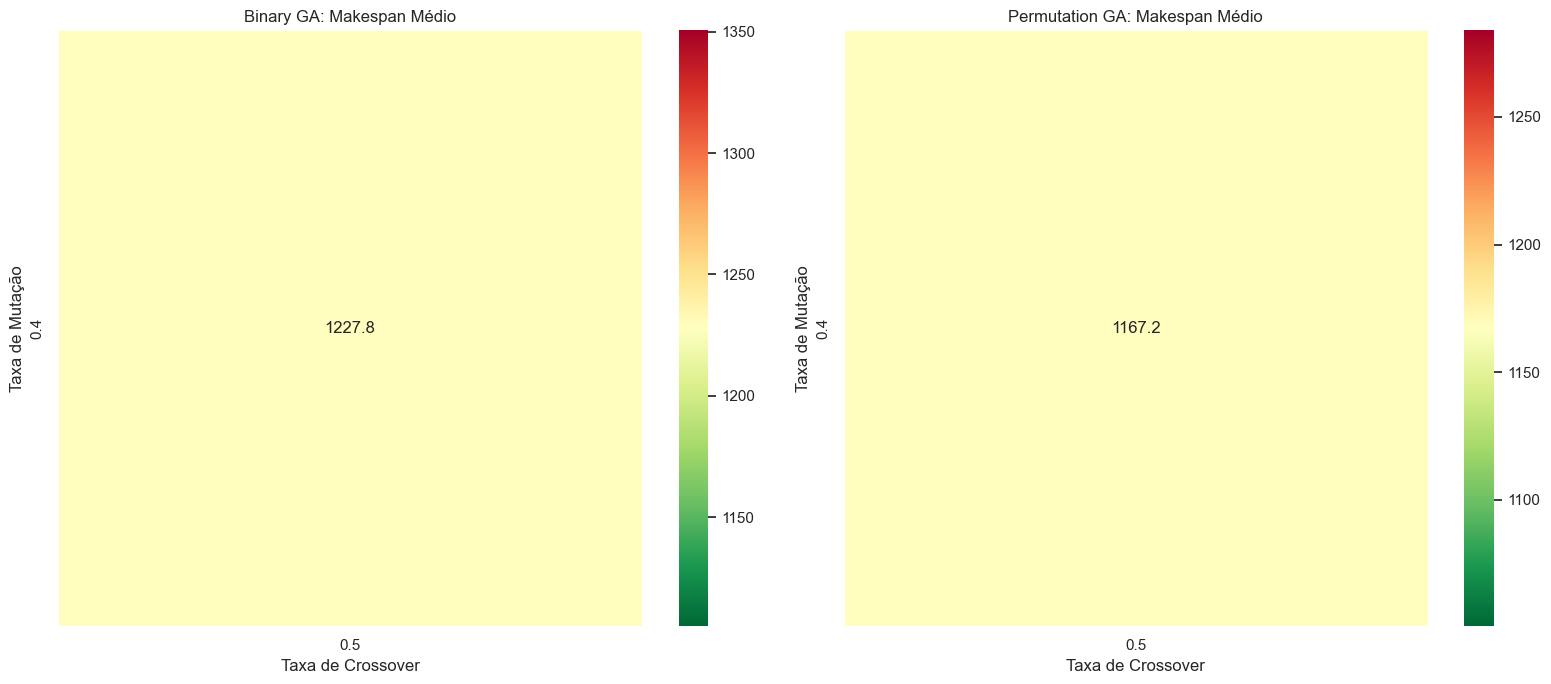


=== VENCEDORES DO GRID SEARCH ===
 Melhor Binary:      Cross=0.5, Mut=0.4 -> Makespan: 1227.80
 Melhor Permutation: Cross=0.5, Mut=0.4 -> Makespan: 1167.20


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração estética
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (16, 7)})

# ==============================================================================
# 1. PREPARAÇÃO DOS DADOS (AGRUPAMENTO)
# ==============================================================================
# Agrupar por Método, Cross Rate e Mut Rate para obter a média do Makespan
# Isto transforma as 125 linhas em 25 pontos médios por método
grid_data = df_results.groupby(['Method', 'Cross Rate', 'Mut Rate'])['Makespan'].mean().reset_index()

# ==============================================================================
# 2. CRIAÇÃO DOS HEATMAPS
# ==============================================================================
fig, axes = plt.subplots(1, 2)

# --- Heatmap 1: Binary GA ---
# Pivotar os dados para formato de matriz (linhas=Mutação, colunas=Crossover)
pivot_bin = grid_data[grid_data['Method'] == 'Binary'].pivot(
    index='Mut Rate', 
    columns='Cross Rate', 
    values='Makespan'
)

# Criar o heatmap
sns.heatmap(pivot_bin, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=axes[0], linewidths=.5)
axes[0].set_title('Binary GA: Makespan Médio')
axes[0].set_xlabel('Taxa de Crossover')
axes[0].set_ylabel('Taxa de Mutação')
axes[0].invert_yaxis()

# --- Heatmap 2: Permutation GA ---
pivot_perm = grid_data[grid_data['Method'] == 'Permutation'].pivot(
    index='Mut Rate', 
    columns='Cross Rate', 
    values='Makespan'
)

sns.heatmap(pivot_perm, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=axes[1], linewidths=.5)
axes[1].set_title('Permutation GA: Makespan Médio')
axes[1].set_xlabel('Taxa de Crossover')
axes[1].set_ylabel('Taxa de Mutação')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. EXTRAÇÃO DOS Melhores
# ==============================================================================
best_bin = grid_data[grid_data['Method'] == 'Binary'].sort_values('Makespan').iloc[0]
best_perm = grid_data[grid_data['Method'] == 'Permutation'].sort_values('Makespan').iloc[0]

print("\n=== VENCEDORES DO GRID SEARCH ===")
print(f" Melhor Binary:      Cross={best_bin['Cross Rate']}, Mut={best_bin['Mut Rate']} -> Makespan: {best_bin['Makespan']:.2f}")
print(f" Melhor Permutation: Cross={best_perm['Cross Rate']}, Mut={best_perm['Mut Rate']} -> Makespan: {best_perm['Makespan']:.2f}")

Method       | Pop Size | Seed | Makespan | Conv Gen
------------------------------------------------------------
Best of the initial population: {'genotype': [1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1], 'phenotype': [1, 2, 4, 7, 9, 10, 11, 12, 13, 14, 16, 17, 19, 20, 21, 22, 23, 26, 28, 29, 30, 31, 33, 34, 37, 39, 40, 41, 42, 43, 45, 46, 47, 52, 53, 56, 59, 60, 62, 63, 64, 65, 66, 67, 70, 71, 72, 75, 76, 78, 79, 81, 84, 88, 91, 97, 0, 3, 5, 6, 8, 15, 18, 24, 25, 27, 32, 35, 36, 38, 44, 48, 49, 50, 51, 54, 55, 57, 58, 61, 68, 69, 73, 74, 77, 80, 82, 83, 85, 86, 87, 89, 90, 92, 93, 94, 95, 96, 98, 99], 'fitness': np.float64(1277.0)}
Best of generation 0 fitness:  1277.0
Best of generation 1 fitness:  1274.0
Best of generation 2 fitnes

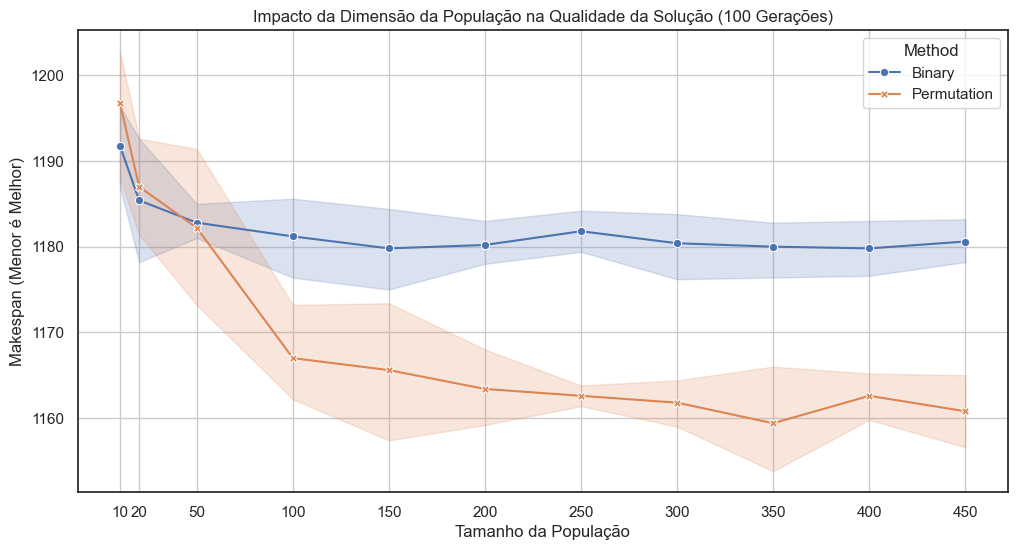

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import random
import copy



# --- CONFIGURAÇÃO DO TESTE DE POPULAÇÃO ---
NUM_GENERATIONS = 100
pop_sizes_to_test = [10, 20, 50, 100,150,200,250,300,350,400,450]
seeds = [100, 200, 300, 400, 500]

best_binary_cfg = {'cross': 0.6, 'mut': 0.05}
best_perm_cfg   = {'cross': 0.5, 'mut': 0.4}

results_pop = []

print(f"{'Method':<12} | {'Pop Size':<8} | {'Seed':<4} | {'Makespan':<8} | {'Conv Gen':<8}")
print("-" * 60)

for pop_size in pop_sizes_to_test:
    POP_SIZE = pop_size 
    
    for seed in seeds:
        random.seed(seed)
        
        # --- Binary (Config Vencedora) ---
        _, bin_mk, _, bin_conv = binary_ga(
            bin_sel, bin_cx, bin_mt, bin_surv, 
            crossover_rate=best_binary_cfg['cross'], 
            mutation_rate=best_binary_cfg['mut']
        )
        
        # --- Permutation (Config Vencedora) ---
        _, perm_mk, _, perm_conv = permutation_ga(
            perm_sel, perm_cx, perm_mt, perm_surv, 
            crossover_rate=best_perm_cfg['cross'], 
            mutation_rate=best_perm_cfg['mut']
        )
        
        results_pop.append({'Method': 'Binary', 'Pop Size': pop_size, 'Makespan': bin_mk, 'Convergence': bin_conv})
        results_pop.append({'Method': 'Permutation', 'Pop Size': pop_size, 'Makespan': perm_mk, 'Convergence': perm_conv})

        print(f"{'Binary':<12} | {pop_size:<8} | {seed:<4} | {bin_mk:<8} | {bin_conv:<8}")
        print(f"{'Permutation':<12} | {pop_size:<8} | {seed:<4} | {perm_mk:<8} | {perm_conv:<8}")
    print("-" * 60)

# --- ANÁLISE ---
df_pop = pd.DataFrame(results_pop)
summary_pop = df_pop.groupby(['Method', 'Pop Size']).agg(
    Avg_Makespan=('Makespan', 'mean'),
    Std_Makespan=('Makespan', 'std'),
    Avg_Conv=('Convergence', 'mean')
).reset_index()

print("\n=== IMPACTO DO TAMANHO DA POPULAÇÃO ===")
print(summary_pop)

# --- PLOT ---
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_pop, x="Pop Size", y="Makespan", hue="Method", style="Method", markers=True, dashes=False)
plt.title("Impacto da Dimensão da População na Qualidade da Solução (100 Gerações)")
plt.ylabel("Makespan (Menor é Melhor)")
plt.xlabel("Tamanho da População")
plt.xticks(pop_sizes_to_test)
plt.grid(True)
plt.show()